## Bonus Assignment week 5 - Netflix database

In [19]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')

### 1. The file 'netflix_titles_nov_2019.csv' contains information on Netflix movies and TV shows. Load the file into a pandas DataFrame, explore it and clean it by removing duplicates with the same title, country, type and release_year.

In [20]:
df = pd.read_csv('netflix_titles_nov_2019.csv', delimiter=',', skipinitialspace=True)

df = df.drop_duplicates(subset=['title', 'country', 'type', 'release_year'])

### 2. Make a pie plot showing the proportion of each type of show in the database.

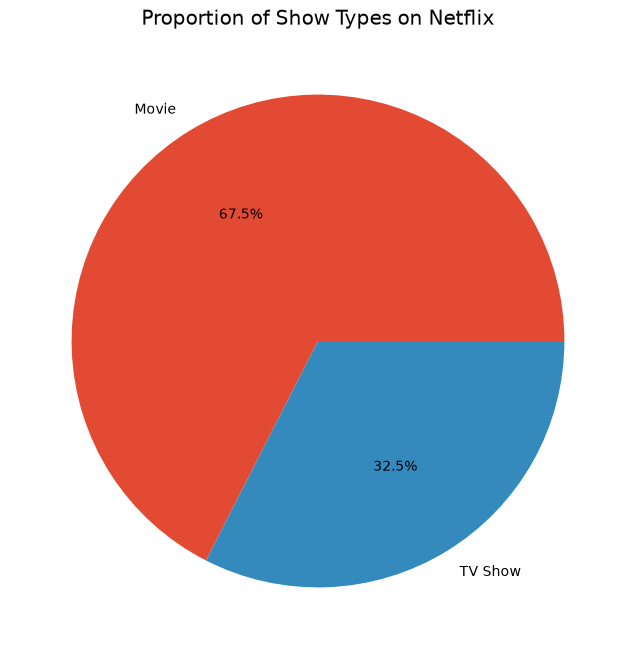

In [21]:
type_counts = df['type'].value_counts()

type_counts.plot(
    kind='pie', 
    autopct='%1.1f%%',
    figsize=(8, 8), 
    title='Proportion of Show Types on Netflix'
)

plt.ylabel('')
plt.show()

### 3. How many entries have nan ratings? Replace the nan ratings by the most frequent rating value (the mode).

In [22]:
print(df['rating'].isnull().sum())

mode = df['rating'].mode()[0]

df['rating'] = df['rating'].fillna(mode)

print(df['rating'].isnull().sum())

10
0


### 4. Transform the column date_added to datetime format and create an additional column with the year a show was added. Make a bar plot with the amount of added content per year.

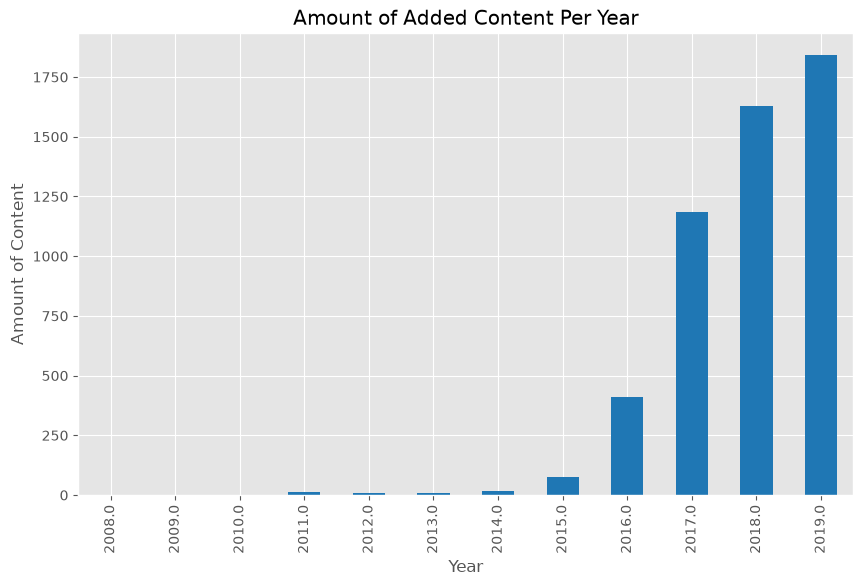

In [24]:
df['date_added'] = pd.to_datetime(df['date_added'])
df['year_added'] = df['date_added'].dt.year

df['year_added'].value_counts().sort_index().plot(
    kind='bar',
    figsize=(10, 6),
    title='Amount of Added Content Per Year',
    color='tab:blue'
)

plt.xlabel('Year')
plt.ylabel('Amount of Content')
plt.show()

### 5. The two types of content on Netflix are Movies and TV Shows. Make a plot of the cumulative growth in content for both categories to show how the numbers evolve over time.

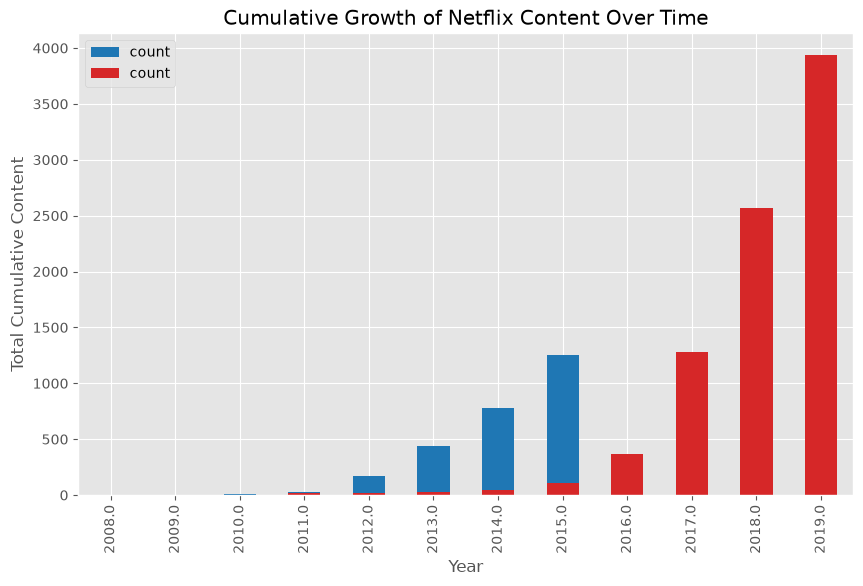

In [34]:
shows = df[df.type == 'TV Show']
movies = df[df.type == 'Movie']

shows['year_added'].value_counts().sort_index().cumsum().plot(
    kind='bar',
    figsize=(10, 6),
    title='Amount of shows Content Per Year',
    color='tab:blue'
)

movies['year_added'].value_counts().sort_index().cumsum().plot(
    kind='bar',
    figsize=(10, 6),
    title='Amount of shows Content Per Year',
    color='tab:red'
)

plt.title('Cumulative Growth of Netflix Content Over Time')
plt.xlabel('Year')
plt.ylabel('Total Cumulative Content')
plt.legend()
plt.show()


### 6. Make a bar chart with the 10 most frequent tv show actors (casts) in UK TV Shows.

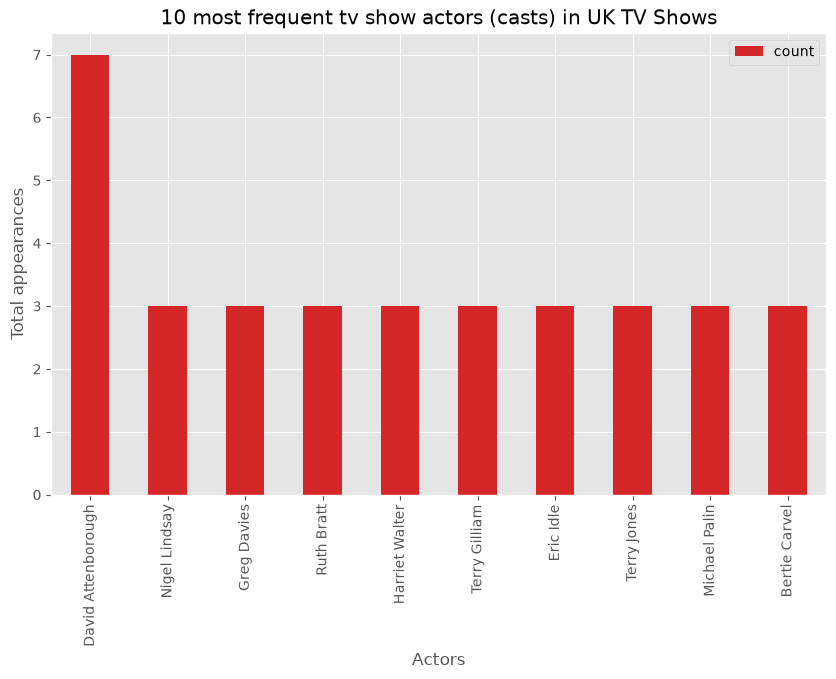

In [43]:
Uk = df[df.country == 'United Kingdom']
uk_shows = Uk[Uk.type == 'TV Show']
uk_shows['cast'].dropna().str.split(',').explode().value_counts().head(10).plot(
    kind='bar',
    figsize=(10, 6),
    title='10 most frequent tv show actors (casts) in UK TV Shows',
    color='tab:red'
)
plt.title('10 most frequent tv show actors (casts) in UK TV Shows')
plt.xlabel('Actors')
plt.ylabel('Total appearances')
plt.legend()
plt.show()


### 7. The countries that are generating the most content are the United States and India. Make a pie chart with number of content items generated by these two countries.

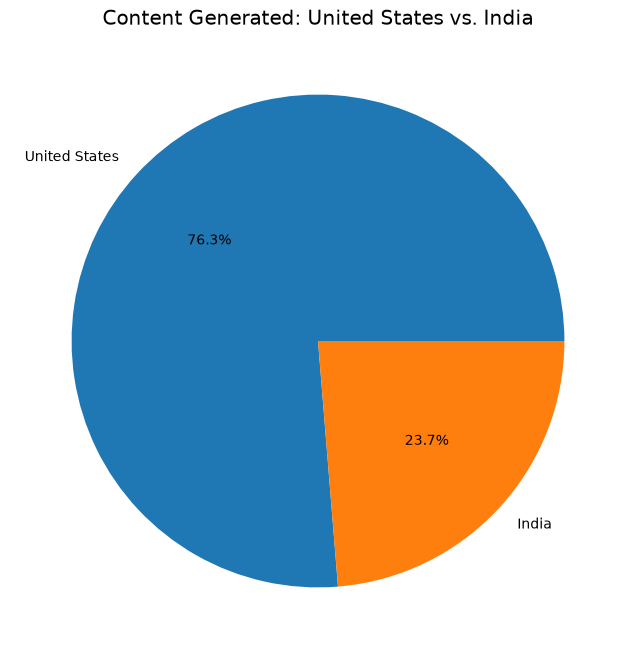

In [49]:
cleanCountries = df['country'].dropna().str.split(', ').explode()

UsIndia = cleanCountries[cleanCountries.isin(['United States', 'India'])]

UsIndia.value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(8, 8),
    title='Content Generated: United States vs. India',
    colors=['tab:blue', 'tab:orange']
)
plt.show()



### 8. What is the largest number of seasons of a TV Show on Netflix?

In [59]:
shows = df[df.type == 'TV Show']
max = shows['duration'].dropna().str.extract(r'(\d+)')[0].max()
print(max)

9


### 9. For each combination of content type and rating, find the most recent release year.

In [60]:
releases = df.groupby(['type', 'rating'])
releases['release_year'].max()

type     rating  
Movie    G           2018
         NC-17       2018
         NR          2019
         PG          2019
         PG-13       2019
         R           2019
         TV-14       2019
         TV-G        2019
         TV-MA       2019
         TV-PG       2019
         TV-Y        2019
         TV-Y7       2019
         TV-Y7-FV    2019
         UR          2016
TV Show  G           2016
         NR          2019
         R           2016
         TV-14       2019
         TV-G        2019
         TV-MA       2020
         TV-PG       2019
         TV-Y        2019
         TV-Y7       2019
         TV-Y7-FV    2019
Name: release_year, dtype: int64